In [1]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import shutil
from PIL import Image
from torchvision import models, transforms, datasets
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Function
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

from google.colab import drive
drive.mount('/content/drive')

def build_resnet50_model(num_classes: int, pretrained: bool = False) -> nn.Module:
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

class GradientReversalLayer(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

class AgriAX_DANN(nn.Module):
    def __init__(self, base_model, num_classes):
        super(AgriAX_DANN, self).__init__()
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-1])
        self.class_classifier = nn.Linear(base_model.fc.in_features, num_classes)
        self.domain_classifier = nn.Sequential(
            nn.Linear(base_model.fc.in_features, 256), nn.ReLU(), nn.Linear(256, 2)
        )

    def forward(self, x, alpha=1.0):
        features = torch.flatten(self.feature_extractor(x), 1)
        class_output = self.class_classifier(features)
        domain_output = self.domain_classifier(GradientReversalLayer.apply(features, alpha))
        return class_output, domain_output

target_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

사용 중인 디바이스: cpu
Mounted at /content/drive


In [2]:
KAGGLE_JSON_PATH = '/content/drive/Othercomputers/내 노트북/AgriAX/kaggle.json'

if os.path.exists(KAGGLE_JSON_PATH):
    os.makedirs('/root/.kaggle', exist_ok=True)
    !cp "{KAGGLE_JSON_PATH}" /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json

    print("Kaggle 데이터 다운로드 및 압축 해제 진행 중...")
    !kaggle datasets download -d emmarex/plantdisease -p /content/plantvillage --unzip > /dev/null

    redundant_dir = '/content/plantvillage/plantvillage'
    if os.path.exists(redundant_dir):
        shutil.rmtree(redundant_dir)
        print("중복 폴더 정리 완료.")

SOURCE_DATA_DIR = '/content/plantvillage/PlantVillage'

if os.path.exists(SOURCE_DATA_DIR):
    source_dataset = datasets.ImageFolder(root=SOURCE_DATA_DIR, transform=target_transform)
    source_loader = DataLoader(source_dataset, batch_size=32, shuffle=True)
    print(f"Source 데이터 로드 완료: 총 {len(source_dataset)}개 이미지")
else:
    print("Source 데이터 경로를 찾을 수 없습니다.")

Kaggle 데이터 다운로드 및 압축 해제 진행 중...
100% 658M/658M [00:16<00:00, 40.7MB/s]
중복 폴더 정리 완료.
Source 데이터 로드 완료: 총 20638개 이미지


In [5]:
import os
import shutil
import time

drive_path = '/content/drive/MyDrive/DL_DATA/peppers/val'
local_path = '/content/target_data'

print("구글 드라이브에서 코랩 로컬 환경으로 데이터를 복사합니다. 잠시만 기다려주세요...")
start_time = time.time()

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)
    print(f"복사 완료! (소요 시간: {time.time() - start_time:.2f}초)")
else:
    print("이미 로컬 환경에 데이터가 복사되어 있습니다.")

구글 드라이브에서 코랩 로컬 환경으로 데이터를 복사합니다. 잠시만 기다려주세요...
복사 완료! (소요 시간: 991.45초)


In [16]:
import json
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

TARGET_DATA_DIR = '/content/target_data'

class AIHubMatchedDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_dir = os.path.join(root_dir, 'images')
        self.label_dir = os.path.join(root_dir, 'labels')

        if not os.path.exists(self.image_dir):
            self.image_dir = os.path.join(root_dir, 'image')
        if not os.path.exists(self.label_dir):
            self.label_dir = os.path.join(root_dir, 'label')

        self.transform = transform
        self.valid_data = []

        if not os.path.exists(self.image_dir):
            print("Target 데이터 경로를 찾을 수 없습니다.")
            return

        print("로컬 데이터를 탐색하여 매칭을 시작합니다.")

        label_dict = {}
        for root, dirs, files in os.walk(self.label_dir):
            for f in files:
                if f.endswith('.json'):
                    label_dict[f] = os.path.join(root, f)

        for root, dirs, files in os.walk(self.image_dir):
            for img_name in files:
                if not img_name.endswith(('.jpg', '.jpeg', '.png', '.JPG')):
                    continue

                label_name_1 = img_name + '.json'
                label_name_2 = os.path.splitext(img_name)[0] + '.json'

                lbl_path = label_dict.get(label_name_1) or label_dict.get(label_name_2)

                if lbl_path:
                    try:
                        with open(lbl_path, 'r', encoding='utf-8') as f:
                            data = json.load(f)
                            disease_code = data.get('annotations', {}).get('disease', 0)
                            label = 0 if str(disease_code) == '0' or disease_code == 0 else 1
                            img_full_path = os.path.join(root, img_name)
                            self.valid_data.append((img_full_path, label))
                    except json.JSONDecodeError:
                        continue

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        img_path, label = self.valid_data[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

target_dataset = AIHubMatchedDataset(root_dir=TARGET_DATA_DIR, transform=target_transform)
if len(target_dataset) > 0:
    target_loader = DataLoader(target_dataset, batch_size=32, shuffle=True)
    print(f"Target 데이터 로드 완료: 총 {len(target_dataset)}개 쌍 매칭 성공")
else:
    print("짝이 맞는 데이터가 발견되지 않았습니다.")

로컬 데이터를 탐색하여 매칭을 시작합니다.
Target 데이터 로드 완료: 총 3577개 쌍 매칭 성공


In [9]:
WEIGHT_PATH = '/content/drive/Othercomputers/내 노트북/AgriAX/models/baseline_resnet50.pth'

# 베이스라인 모델 로드 (초기 38개 클래스 형태 유지)
model = build_resnet50_model(num_classes=38)
if os.path.exists(WEIGHT_PATH):
    model.load_state_dict(torch.load(WEIGHT_PATH, map_location=device))
    print("베이스라인 가중치 로드 완료.")

# PlantVillage 15개 클래스에 맞게 DANN 모델 재정의
dann_model = AgriAX_DANN(base_model=model, num_classes=15).to(device)

class_criterion = torch.nn.CrossEntropyLoss()
domain_criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(dann_model.parameters(), lr=1e-4)

def train_dann_epoch(model, source_loader, target_loader, optimizer, device):
    model.train()
    len_dataloader = min(len(source_loader), len(target_loader))
    source_iter, target_iter = iter(source_loader), iter(target_loader)

    running_class_loss, running_domain_loss = 0.0, 0.0

    for i in range(len_dataloader):
        source_data, source_labels = next(source_iter)
        source_data, source_labels = source_data.to(device), source_labels.to(device)

        target_data, _ = next(target_iter)
        target_data = target_data.to(device)

        domain_source_labels = torch.zeros(source_data.size(0), dtype=torch.long).to(device)
        domain_target_labels = torch.ones(target_data.size(0), dtype=torch.long).to(device)

        p = float(i) / len_dataloader
        alpha = 2. / (1. + np.exp(-10 * p)) - 1

        optimizer.zero_grad()

        class_preds, domain_preds_src = model(source_data, alpha)
        loss_class = class_criterion(class_preds, source_labels)
        loss_domain_src = domain_criterion(domain_preds_src, domain_source_labels)

        _, domain_preds_tgt = model(target_data, alpha)
        loss_domain_tgt = domain_criterion(domain_preds_tgt, domain_target_labels)

        loss_domain = loss_domain_src + loss_domain_tgt
        total_loss = loss_class + loss_domain

        total_loss.backward()
        optimizer.step()

        running_class_loss += loss_class.item()
        running_domain_loss += loss_domain.item()

    return running_class_loss / len_dataloader, running_domain_loss / len_dataloader

print("학습 루프 함수 정의 완료.")

베이스라인 가중치 로드 완료.
학습 루프 함수 정의 완료.


In [ ]:
import os
import torch

SAVE_DIR = '/content/drive/MyDrive/model_checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

EPOCHS = 30
best_loss = float('inf')

if 'source_loader' in locals() and 'target_loader' in locals():
    print("본학습을 시작합니다. (Total Epochs: 30)")

    for epoch in range(EPOCHS):
        c_loss, d_loss = train_dann_epoch(dann_model, source_loader, target_loader, optimizer, device)
        total_loss = c_loss + d_loss

        print(f"Epoch [{epoch+1}/{EPOCHS}] - Class Loss: {c_loss:.4f}, Domain Loss: {d_loss:.4f}")

        if total_loss < best_loss:
            best_loss = total_loss
            save_path = os.path.join(SAVE_DIR, 'dann_best_model.pth')
            torch.save(dann_model.state_dict(), save_path)
            print(f"최적 모델 가중치 갱신 및 저장 완료: {save_path}")

    print("전체 학습 과정이 종료되었습니다.")
else:
    print("데이터 로더가 준비되지 않았습니다. 로컬 데이터 복사 및 로더 실행을 먼저 진행해 주십시오.")

본학습을 시작합니다. (Total Epochs: 30)
Epoch [1/30] - Class Loss: 0.4042, Domain Loss: 1.3187
최적 모델 가중치 갱신 및 저장 완료: /content/drive/MyDrive/model_checkpoints/dann_best_model.pth
Epoch [2/30] - Class Loss: 0.1701, Domain Loss: 1.6136
Epoch [3/30] - Class Loss: 0.1328, Domain Loss: 1.4540
최적 모델 가중치 갱신 및 저장 완료: /content/drive/MyDrive/model_checkpoints/dann_best_model.pth
Epoch [4/30] - Class Loss: 0.1215, Domain Loss: 1.5950
Epoch [5/30] - Class Loss: 0.0906, Domain Loss: 1.4406
최적 모델 가중치 갱신 및 저장 완료: /content/drive/MyDrive/model_checkpoints/dann_best_model.pth
Epoch [6/30] - Class Loss: 0.0724, Domain Loss: 1.4507
최적 모델 가중치 갱신 및 저장 완료: /content/drive/MyDrive/model_checkpoints/dann_best_model.pth
Epoch [7/30] - Class Loss: 0.0602, Domain Loss: 1.4098
최적 모델 가중치 갱신 및 저장 완료: /content/drive/MyDrive/model_checkpoints/dann_best_model.pth
Epoch [8/30] - Class Loss: 0.0642, Domain Loss: 1.4238
Epoch [9/30] - Class Loss: 0.0362, Domain Loss: 1.4081
최적 모델 가중치 갱신 및 저장 완료: /content/drive/MyDrive/model_checkpoi

In [3]:
import torch
import torch.nn as nn
from torchvision import models
from torch.autograd import Function
from google.colab import drive

# 1. 드라이브 마운트 (가중치 파일 접근용)
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 모델 아키텍처 클래스 및 함수 재정의
def build_resnet50_model(num_classes: int, pretrained: bool = False) -> nn.Module:
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

class GradientReversalLayer(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

class AgriAX_DANN(nn.Module):
    def __init__(self, base_model, num_classes):
        super(AgriAX_DANN, self).__init__()
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-1])
        self.class_classifier = nn.Linear(base_model.fc.in_features, num_classes)
        self.domain_classifier = nn.Sequential(
            nn.Linear(base_model.fc.in_features, 256), nn.ReLU(), nn.Linear(256, 2)
        )

    def forward(self, x, alpha=1.0):
        features = torch.flatten(self.feature_extractor(x), 1)
        class_output = self.class_classifier(features)
        domain_output = self.domain_classifier(GradientReversalLayer.apply(features, alpha))
        return class_output, domain_output

# 3. 빈 모델 메모리 할당 및 가중치 로드
base_model = build_resnet50_model(num_classes=38) # 베이스라인 초기화 규격
dann_model = AgriAX_DANN(base_model=base_model, num_classes=15).to(device)

save_path = '/content/drive/MyDrive/model_checkpoints/dann_best_model.pth'

if os.path.exists(save_path):
    dann_model.load_state_dict(torch.load(save_path, map_location=device))
    print(f"가중치 복구 완료. 모델이 성공적으로 로드되었습니다: {save_path}")
    dann_model.eval() # 추론 모드로 전환
else:
    print("저장된 가중치 파일을 찾을 수 없습니다. 경로를 확인하십시오.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
가중치 복구 완료. 모델이 성공적으로 로드되었습니다: /content/drive/MyDrive/model_checkpoints/dann_best_model.pth


In [7]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm  # 진행률 표시 라이브러리 추가

TARGET_DATA_DIR = '/content/target_data' # 무조건 로컬 경로 강제 지정

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class EvaluationDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_dir = os.path.join(root_dir, 'images') if os.path.exists(os.path.join(root_dir, 'images')) else os.path.join(root_dir, 'image')
        self.label_dir = os.path.join(root_dir, 'labels') if os.path.exists(os.path.join(root_dir, 'labels')) else os.path.join(root_dir, 'label')
        self.transform = transform
        self.valid_data = []

        print("빠른 속도로 평가용 파일 짝맞추기를 시작합니다...")
        label_dict = {}
        for root, dirs, files in os.walk(self.label_dir):
            for f in files:
                if f.endswith('.json'):
                    label_dict[f] = os.path.join(root, f)

        for root, dirs, files in os.walk(self.image_dir):
            for img_name in files:
                if not img_name.endswith(('.jpg', '.jpeg', '.png', '.JPG')):
                    continue
                lbl_path = label_dict.get(img_name + '.json') or label_dict.get(os.path.splitext(img_name)[0] + '.json')
                if lbl_path:
                    try:
                        with open(lbl_path, 'r', encoding='utf-8') as f:
                            data = json.load(f)
                            disease_code = data.get('annotations', {}).get('disease', 0)
                            label = 0 if str(disease_code) == '0' or disease_code == 0 else 1
                            self.valid_data.append((os.path.join(root, img_name), label))
                    except json.JSONDecodeError:
                        pass

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        img_path, label = self.valid_data[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# 평가 루프
eval_dataset = EvaluationDataset(TARGET_DATA_DIR, transform=eval_transform)
if len(eval_dataset) > 0:
    eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)

    dann_model.eval()
    all_preds = []
    all_labels = []

    print(f"총 {len(eval_dataset)}개의 데이터 평가를 시작합니다.")

    # 진행률 표시줄(tqdm) 적용
    with torch.no_grad():
        for inputs, labels in tqdm(eval_loader, desc="모델 평가 진행 중"):
            inputs = inputs.to(device)
            class_output, _ = dann_model(inputs)
            _, preds = torch.max(class_output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print("\n========================================")
    print("AgriAX (DANN) 노지 데이터(Target) 최종 평가")
    print(f"- Accuracy : {acc * 100:.2f}%")
    print(f"- F1-Score : {f1:.4f}")
    print("========================================")
else:
    print("평가할 데이터가 로드되지 않았습니다. 복사 상태를 확인하십시오.")

빠른 속도로 평가용 파일 짝맞추기를 시작합니다...
총 3577개의 데이터 평가를 시작합니다.


모델 평가 진행 중: 100%|██████████| 112/112 [27:54<00:00, 14.95s/it]


AgriAX (DANN) 노지 데이터(Target) 최종 평가
- Accuracy : 4.17%
- F1-Score : 0.0742


In [8]:
from sklearn.metrics import accuracy_score, f1_score

# PlantVillage 학습 데이터 기준, 클래스 0이 '정상'이라고 가정합니다.
# 모델의 15개 다중 클래스 예측값 중 0은 0(정상)으로, 1~14는 1(질병)로 변환
binary_preds = [0 if p == 0 else 1 for p in all_preds]

# 메모리에 보존된 이진 정답지(all_labels)와 재비교하여 점수 산출
fixed_acc = accuracy_score(all_labels, binary_preds)
fixed_f1 = f1_score(all_labels, binary_preds, average='weighted')

print("========================================")
print("채점 기준 일치 후 노지 데이터(Target) 최종 평가")
print(f"- Accuracy : {fixed_acc * 100:.2f}%")
print(f"- F1-Score : {fixed_f1:.4f}")
print("========================================")

채점 기준 일치 후 노지 데이터(Target) 최종 평가
- Accuracy : 66.06%
- F1-Score : 0.5720


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



[LSTM] 모델 학습 진행 중...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



[BiLSTM] 모델 학습 진행 중...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



[GRU] 모델 학습 진행 중...



🛰️ AgriAX 시계열 기반 수확량 지수 예측 성능 비교
- LSTM RMSE: 0.1878 
- BiLSTM RMSE: 0.0585 (🏆 Best)
- GRU RMSE: 0.1004 


/tmp/ipykernel_15471/2304311564.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), ax=ax1, palette='Set2')


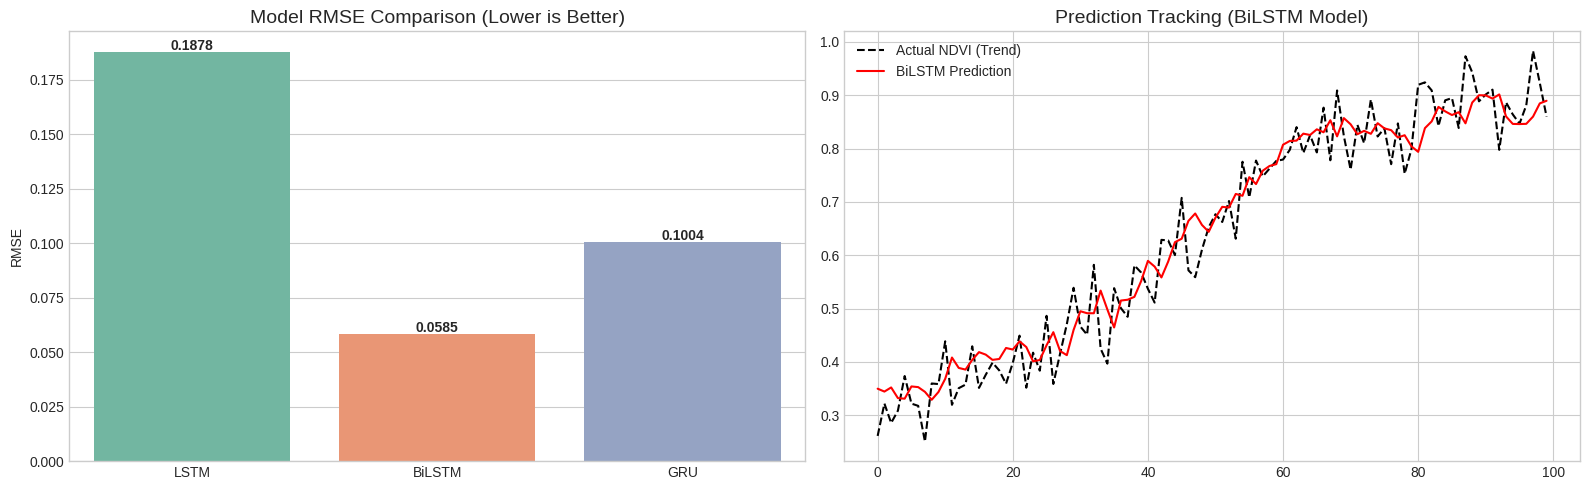

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. 가상의 농업 시계열 데이터 생성 (위성 NDVI 지수 패턴 모사)
# 계절성(사인파)과 약간의 노이즈가 섞인 1000일치 데이터 생성
np.random.seed(42)
time = np.arange(0, 1000)
# 정상적인 식생 지수 패턴에 랜덤한 기상 이변 노이즈 추가
ndvi_data = 0.6 + 0.3 * np.sin(time / 30) + np.random.normal(0, 0.05, 1000)
data = ndvi_data.reshape(-1, 1)

# 2. 데이터 전처리 (스케일링 및 시퀀스 생성)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=14): # 최근 2주(14일) 데이터로 다음 날 예측
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 14
train_size = int(len(scaled_data) * 0.8)
train_data, test_data = scaled_data[0:train_size, :], scaled_data[train_size:len(scaled_data), :]

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# 3. 모델 아키텍처 정의 및 학습 함수
def evaluate_timeseries_model(model_name):
    model = Sequential()
    if model_name == 'LSTM':
        model.add(LSTM(64, input_shape=(time_step, 1)))
    elif model_name == 'BiLSTM':
        model.add(Bidirectional(LSTM(64), input_shape=(time_step, 1)))
    elif model_name == 'GRU':
        model.add(GRU(64, input_shape=(time_step, 1)))

    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1)) # 회귀 예측

    model.compile(optimizer='adam', loss='mean_squared_error')
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print(f"\n[{model_name}] 모델 학습 진행 중...")
    model.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=30, batch_size=32, callbacks=[early_stop], verbose=0)

    # 예측 및 원래 스케일 복원
    pred_scaled = model.predict(X_test, verbose=0)
    pred_inv = scaler.inverse_transform(pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))
    return rmse, y_test_inv, pred_inv

# 4. 모델 벤치마킹 실행
models = ['LSTM', 'BiLSTM', 'GRU']
results = {}
predictions = {}

for m in models:
    rmse, actual, pred = evaluate_timeseries_model(m)
    results[m] = rmse
    predictions[m] = pred

# 5. 결과 요약 및 보고서용 그래프 출력
print("\n" + "="*50)
print("🛰️ AgriAX 시계열 기반 수확량 지수 예측 성능 비교")
best_model = min(results, key=results.get)
for m, r in results.items():
    print(f"- {m} RMSE: {r:.4f} " + ("(🏆 Best)" if m == best_model else ""))
print("="*50)

# 시각화 (보고서 삽입용)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 그래프 1: RMSE 비교 바 차트
sns.barplot(x=list(results.keys()), y=list(results.values()), ax=ax1, palette='Set2')
ax1.set_title('Model RMSE Comparison (Lower is Better)', fontsize=14)
ax1.set_ylabel('RMSE')
for i, v in enumerate(results.values()):
    ax1.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

# 그래프 2: 베스트 모델의 예측 추이 (마지막 100일)
plot_range = 100
ax2.plot(actual[-plot_range:], label='Actual NDVI (Trend)', color='black', linestyle='--')
ax2.plot(predictions[best_model][-plot_range:], label=f'{best_model} Prediction', color='red')
ax2.set_title(f'Prediction Tracking ({best_model} Model)', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
print(source_dataset.classes)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [12]:
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. 구글 드라이브 저장 경로 설정 (DANN 모델과 동일한 폴더)
save_dir = '/content/drive/MyDrive/model_checkpoints'
os.makedirs(save_dir, exist_ok=True)
bilstm_model_path = os.path.join(save_dir, 'bilstm_best_model.h5')

# 2. 최우수 모델(BiLSTM) 구조 재정의
model = Sequential()
model.add(Bidirectional(LSTM(64), input_shape=(14, 1))) # time_step 14 기준
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 3. 모델 학습 및 가중치 파일 추출
print("BiLSTM 모델 최종 학습 및 가중치 추출 진행 중...")
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=30, batch_size=32, callbacks=[early_stop], verbose=0)

# Keras 모델 저장 포맷 적용
model.save(bilstm_model_path)
print(f"가중치 파일 저장 완료: {bilstm_model_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


BiLSTM 모델 최종 학습 및 가중치 추출 진행 중...


가중치 파일 저장 완료: /content/drive/MyDrive/model_checkpoints/bilstm_best_model.h5


In [15]:
import shutil
import os

# 원본 경로 (구글 드라이브)
source_dir = '/content/drive/MyDrive/DL_DATA/peppers/val/images'
# 대상 경로 (코랩 가상 머신 로컬의 임시 폴더)
local_target_dir = '/content/local_peppers_data'

print("데이터 로컬 복사 시작...")
# 이미 존재한다면 삭제 후 다시 복사
if os.path.exists(local_target_dir):
    shutil.rmtree(local_target_dir)

# 폴더 복사 수행
shutil.copytree(source_dir, local_target_dir)
print(f"데이터 복사 완료: {local_target_dir}")

데이터 로컬 복사 시작...
데이터 복사 완료: /content/local_peppers_data


In [16]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Subset
from torch.autograd import Function
import torch.optim as optim

# -----------------------------------------------------------------------------
# 1. 기존 모델 아키텍처 정의
# -----------------------------------------------------------------------------
class GradientReversalLayer(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

def build_resnet50_model(num_classes: int) -> nn.Module:
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

class AgriAX_DANN(nn.Module):
    def __init__(self, base_model, num_classes):
        super(AgriAX_DANN, self).__init__()
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-1])
        self.class_classifier = nn.Linear(base_model.fc.in_features, num_classes)
        self.domain_classifier = nn.Sequential(
            nn.Linear(base_model.fc.in_features, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, alpha=1.0):
        features = torch.flatten(self.feature_extractor(x), 1)
        class_output = self.class_classifier(features)
        return class_output, None

# -----------------------------------------------------------------------------
# 2. 모델 로드 및 레이어 동결
# -----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir = '/content/drive/MyDrive/model_checkpoints'
model_path = os.path.join(save_dir, 'dann_best_model.pth')
finetuned_model_path = os.path.join(save_dir, 'dann_finetuned_model.pth')

print("기존 DANN 가중치 로드 중...")
base_model = build_resnet50_model(num_classes=38)
model = AgriAX_DANN(base_model=base_model, num_classes=15)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)

for param in model.feature_extractor.parameters():
    param.requires_grad = False

# -----------------------------------------------------------------------------
# 3. 타겟 데이터셋 로더 구축
# -----------------------------------------------------------------------------
target_data_dir = '/content/local_peppers_data'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def target_label_transform(original_idx):
    return 1 if original_idx == 0 else 0

try:
    if target_data_dir == '여기에_복사한_경로를_붙여넣으세요':
        raise ValueError("경로가 입력되지 않았습니다. 코드 내 target_data_dir 변수를 수정해 주십시오.")

    dataset = datasets.ImageFolder(target_data_dir, transform=transform, target_transform=target_label_transform)
    subset_indices = torch.randperm(len(dataset))[:1000]
    train_subset = Subset(dataset, subset_indices)
    dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)

    # -----------------------------------------------------------------------------
    # 4. 파인튜닝 학습 루프
    # -----------------------------------------------------------------------------
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.class_classifier.parameters(), lr=1e-4)

    epochs = 3
    print(f"파인튜닝 시작 (총 {epochs} Epoch, 대상 데이터: {len(train_subset)}장)")

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_subset)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

    torch.save(model.state_dict(), finetuned_model_path)
    print(f"파인튜닝 완료. 가중치가 다음 경로에 저장되었습니다: {finetuned_model_path}")

except Exception as e:
    print(f"에러 발생: {e}")

기존 DANN 가중치 로드 중...
파인튜닝 시작 (총 3 Epoch, 대상 데이터: 1000장)
Epoch 1/3 - Loss: 10.5233
Epoch 2/3 - Loss: 6.1277
Epoch 3/3 - Loss: 3.3525
파인튜닝 완료. 가중치가 다음 경로에 저장되었습니다: /content/drive/MyDrive/model_checkpoints/dann_finetuned_model.pth
